# 15장 실습 — 관측 갭 vs 동역학 갭

1장에서 간극을 네 자리로 나눴다. 동역학, 인식, 구동, 시스템이다. 그 뒤로 열세 장 동안 도구를 만들었는데, 실무의 질문은 늘 하나 더 남는다 — **어느 것부터 메울 것인가.**

이 질문에 두 진영이 반대로 답한다. VLA와 모방학습 쪽 사람들은 시각이 전부라고 말하고, 로코모션 강화학습 쪽 사람들은 지연과 구동기가 전부라고 말한다. 둘 다 자기 경험에서 맞는 말을 하고 있다.

이 노트북은 그 둘을 **한 과제 위에 마주 세운다.** 같은 환경, 같은 관측, 같은 크기의 신경망에 학습 방식만 다른 두 정책을 세우고, 양쪽 교란을 똑같이 먹여 본다.

실행 시간은 CPU에서 5분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


## 두 정책, 나머지는 전부 같게

환경은 8장부터 써 온 벡터 환경이다. 교란을 넣을 손잡이가 넷 붙어 있다 — 관측 잡음, 관측 편향, 제어 지연, 바닥 마찰이다. 앞의 둘이 **관측 갭**이고 뒤의 둘이 **동역학 갭**이다.

두 정책을 세운다.

- **강화학습 정책** — 8장의 PPO로 시뮬 안에서 보상을 최대화해 배운다. 시연을 보지 않는다
- **모방학습 정책** — 6장의 서보 전문가가 시연한 것을 지도학습으로 흉내 낸다. 보상을 보지 않는다

관측도 같고, 신경망 크기도 같고, 교란 없는 조건에서의 성적도 비슷하게 맞춘다. **다른 것은 학습 신호 하나뿐**이다.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction="{mu} .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction="{mu} .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="{kv}"/>
    <velocity joint="py" kv="{kv}"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MU, KV = .60, 120.
CACHE = {}


def model_of(mu, kv):
    k = (round(mu, 2), round(kv, 0))
    if k not in CACHE:
        CACHE[k] = mujoco.MjModel.from_xml_string(
            XML.format(mu=k[0], kv=k[1]))
    return CACHE[k]


def unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-9 else np.zeros_like(v)


def expert(b, p, g):
    dv = unit(g - b)
    if np.linalg.norm(g - b) < .012:
        return np.zeros(2)
    e = (b - dv * .045) - p
    if np.linalg.norm(e) > .013:
        u = 14. * e
        n = np.linalg.norm(u)
        return u / n * .22 if n > .22 else u
    return dv * .22


class Vec:
    def __init__(self, n, seed=0, mu=MU, kv=KV, lat=0, noise=0.,
                 bias=(0., 0.)):
        self.m = model_of(mu, kv)
        self.sub = int(round(1 / 20 / self.m.opt.timestep))
        self.n, self.lat, self.noise = n, lat, noise
        self.bias = np.asarray(bias)
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.buf = [None] * n
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
        self.buf[i] = [np.zeros(2)] * (self.lat + 1)

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float) + self.bias
            if self.noise:
                b = b + self.rng.normal(0, self.noise, 2)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            cl = np.clip(a[i], -1, 1)
            self.buf[i].append(cl * AMAX)
            d.ctrl[:] = self.buf[i][-1 - self.lat]
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


class BCNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(8, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 2))

    def forward(self, x):
        return self.f(x)


def collect_bc(n_ep=200, seed=1):
    env = Vec(8, seed)
    X, Y = [], []
    for _ in range(n_ep * EP // 8):
        o = env.obs()
        acts = []
        for i, d in enumerate(env.d):
            b = np.asarray(d.qpos[0:2], float)
            acts.append(expert(b, np.asarray(d.qpos[7:9], float),
                               env.g[i]) / AMAX)
        acts = np.array(acts, np.float32)
        X.append(o)
        Y.append(acts)
        env.step(acts)
    return np.concatenate(X), np.concatenate(Y)


def train_bc(X, Y, seed=0, epochs=150):
    torch.manual_seed(seed)
    net = BCNet()
    opt = torch.optim.Adam(net.parameters(), 1e-3)
    X, Y = torch.from_numpy(X), torch.from_numpy(Y)
    n = len(X)
    for _ in range(epochs):
        idx = torch.randperm(n)
        for k in range(0, n, 256):
            j = idx[k:k + 256]
            loss = ((net(X[j]) - Y[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return net


def score(kind, net, n=150, **kw):
    torch.manual_seed(999)
    env = Vec(8, 999, **kw)
    got = []
    while len(got) < n:
        o = torch.from_numpy(env.obs())
        with torch.no_grad():
            if kind == "rl":
                u = net.dist(o).sample().numpy()
            else:
                u = net(o).numpy()
        got += env.step(u)[2]
    return float(np.mean(got[:n]))

In [5]:
t0 = time.time()
rl = train_rl()
print(f"강화학습 정책 끝  ({time.time()-t0:.0f}s)")
Xb, Yb = collect_bc()
bc = train_bc(Xb, Yb)
print(f"모방학습 정책 끝  ({time.time()-t0:.0f}s)")

BASE = {"rl": score("rl", rl), "bc": score("bc", bc)}
print()
print(pad("정책", 16) + pad("학습 신호", 16, True)
      + pad("교란 없는 성공률", 18, True))
print(pad("강화학습", 16) + pad("보상", 16, True)
      + pad(f"{BASE['rl']:.2f}", 18, True))
print(pad("모방학습", 16) + pad("시연", 16, True)
      + pad(f"{BASE['bc']:.2f}", 18, True))

강화학습 정책 끝  (56s)


모방학습 정책 끝  (70s)



정책                   학습 신호  교란 없는 성공률
강화학습                    보상              0.89
모방학습                    시연              0.91


출발점이 비슷하다. 이제 양쪽에 같은 교란을 먹인다. 성적은 **자기 기준선 대비 비율**로 적는다 — 절대 성공률이 아니라 「얼마나 깎였나」를 견주기 위해서다.

In [6]:
def sweep(label, unit_, values, **mk):
    rows = []
    for v in values:
        kw = mk["fn"](v)
        rows.append((v,
                     score("rl", rl, **kw) / BASE["rl"],
                     score("bc", bc, **kw) / BASE["bc"]))
    print(pad(label, 18) + pad("강화학습", 12, True)
          + pad("모방학습", 12, True))
    for v, r, b in rows:
        print(pad(f"{v}{unit_}", 18) + pad(f"{r:.2f}", 12, True)
              + pad(f"{b:.2f}", 12, True))
    print()
    return rows


t0 = time.time()
noise = sweep("관측 잡음", " mm", [0, 4, 8, 15],
              fn=lambda v: dict(noise=v / 1000))
bias = sweep("관측 편향", " mm", [0, 8, 15, 25],
             fn=lambda v: dict(bias=(v / 1000, -v * .7 / 1000)))
lat = sweep("제어 지연", " 스텝", [0, 1, 2, 3],
            fn=lambda v: dict(lat=v))
fric = sweep("바닥 마찰", "", [.6, .75, .9, 1.1],
             fn=lambda v: dict(mu=v))
print(f"({time.time()-t0:.0f}s)")

관측 잡음             강화학습    모방학습
0 mm                      1.00        1.00
4 mm                      1.02        1.09
8 mm                      0.97        1.08
15 mm                     0.85        0.46



관측 편향             강화학습    모방학습
0 mm                      1.00        1.00
8 mm                      0.87        0.01
15 mm                     0.02        0.00
25 mm                     0.00        0.00



제어 지연             강화학습    모방학습
0 스텝                    1.00        1.00
1 스텝                    0.56        0.93
2 스텝                    0.08        0.84
3 스텝                    0.02        0.42



바닥 마찰             강화학습    모방학습
0.6                       1.00        1.00
0.75                      1.08        0.98
0.9                       1.09        0.93
1.1                       1.08        0.96

(82s)


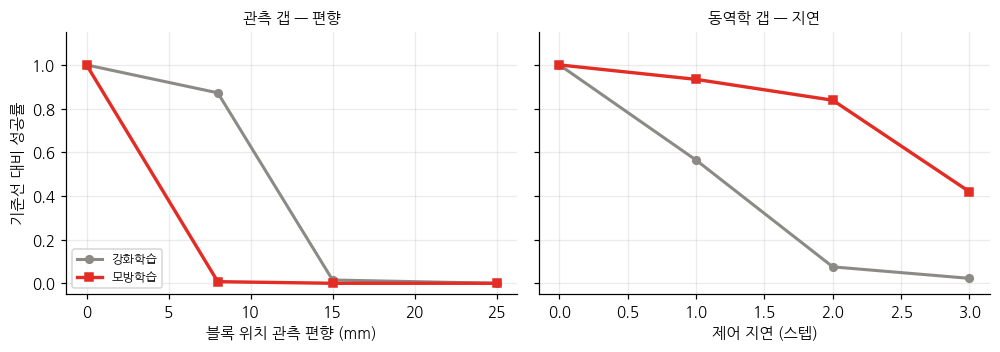

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.2, 3.3), sharey=True)
for ax, rows, ttl, xl in (
        (a1, bias, "관측 갭 — 편향", "블록 위치 관측 편향 (mm)"),
        (a2, lat, "동역학 갭 — 지연", "제어 지연 (스텝)")):
    xs = [r[0] for r in rows]
    ax.plot(xs, [r[1] for r in rows], "o-", color=GREY, lw=2, ms=5,
            label="강화학습")
    ax.plot(xs, [r[2] for r in rows], "s-", color=RED, lw=2.2, ms=5,
            label="모방학습")
    ax.set_title(ttl, fontsize=10)
    ax.set_xlabel(xl)
    ax.set_ylim(-.05, 1.15)
a1.set_ylabel("기준선 대비 성공률")
a1.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

## 왜 반대로 갈리는가

**모방 정책은 관측을 그대로 믿는다.** 배운 것이 「이 관측에서는 이 행동」이라는 사상 하나다. 입력이 8 mm 옆으로 밀리면 출력도 그만큼 밀린 행동이 나오고, 그것을 고칠 장치가 정책 안에 없다. 전문가가 잘못된 관측을 어떻게 다루는지는 시연에 들어 있지 않았다.

**강화학습 정책은 어긋난 관측을 견딘다.** 보상을 최대화하며 배우는 동안 자기 행동의 잡음과 가치 추정의 잡음을 겪었고, 그래서 관측의 세부보다 굵직한 신호에 기대는 정책이 나온다. 조금 어긋나도 대체로 옳은 방향으로 민다.

**지연에서는 정반대가 된다.** 강화학습 정책은 지연 없는 세계에서 보상을 쥐어짜며 **타이밍까지 맞춰 놓았다.** 그 타이밍이 한 스텝만 밀려도 최적화해 둔 것이 전부 어긋난다. 반면 모방 정책이 흉내 낸 전문가는 비례 제어 규칙이고, 비례 제어는 원래 지연에 너그럽다. **정책이 무엇을 흉내 냈는지가 그대로 따라온다.**

> 강화학습은 타이밍을 최적화하고, 모방학습은 관측을 신뢰한다

**마찰은 둘 다 견딘다.** 양쪽 다 피드백으로 고칠 수 있는 종류의 어긋남이고, 10장에서 특권 학습이 이 과제에서 값을 크게 하지 못했던 것과 같은 이유다.

## 그래서 무엇을 먼저 메울 것인가

이 표가 두 진영의 말이 왜 다른지를 설명한다.

VLA와 모방학습 쪽에서 **시각이 전부**라고 말하는 것은 그들의 정책이 관측을 그대로 믿기 때문이다. 카메라 교정이 조금 어긋나거나 렌더링이 실제와 달라 보이면 곧바로 성능이 무너진다. 13장에서 짝 있는 번역이 그토록 값을 했던 것도 이 민감도 때문이다.

로코모션 강화학습 쪽에서 **지연과 구동기가 전부**라고 말하는 것은 그들의 정책이 타이밍을 최적화했기 때문이다. 6장에서 Xie와 동료들이 여러 축을 랜덤화해 봤을 때 **지연만 값을 했다**는 것, 10장에서 지연이 절벽을 만들었다는 것이 같은 이야기다.

둘 다 맞다. 그리고 **서로의 처방을 가져다 쓰면 값을 못 한다.** 모방 정책에 지연 랜덤화를 정성껏 걸어도 카메라가 어긋나 있으면 소용없고, 강화학습 로코모션에 렌더링 품질을 올려도 제어 주기가 밀려 있으면 소용없다.

실무의 규칙으로 옮기면 이렇다.

> 학습 신호를 먼저 보고, 그 다음 어느 갭을 메울지 정한다

## 정리

**같은 과제에서도 어느 갭이 치명적인지가 정책마다 다르다.** 환경도 관측도 신경망 크기도 같게 두고 학습 신호만 바꿨는데 민감도가 반대로 나왔다.

**모방 정책은 관측 갭에 지배된다.** 8 mm 편향에서 사실상 0이 됐다. 배운 것이 관측에서 행동으로 가는 사상 하나뿐이고, 관측이 틀렸을 때 무엇을 해야 하는지는 시연에 없었다.

**강화학습 정책은 동역학 갭, 특히 지연에 지배된다.** 한 스텝에서 반토막, 두 스텝에서 끝이었다. 보상을 쥐어짜며 타이밍까지 맞춰 놓았기 때문이다.

**모방 정책이 지연에 강한 것은 흉내 낸 대상 덕이다.** 비례 제어 전문가를 흉내 냈으니 그 너그러움도 함께 물려받았다. 정책의 강건성은 학습 방식뿐 아니라 **무엇을 흉내 냈는가**에서도 온다.

**두 진영의 상반된 결론이 둘 다 맞다.** 그리고 서로의 처방을 빌려 쓰면 값을 하지 못한다. 어느 갭을 먼저 메울지는 정책의 학습 신호가 정한다.

여기까지가 4부다. 12장에서 섞는 법을, 13장에서 고치는 법을, 14장에서 무엇을 시킬지를, 그리고 이 장에서 어디에 예산을 쓸지를 봤다. 5부는 이 모든 것을 실기로 넘기는 절차를 다룬다.